# Cats VS Dogs

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, numpy as np, matplotlib.pyplot as plt
import os, shutil, random
from IPython.display import clear_output

If you have a MacBook Pro with an M1, M2, M3, or M4 chip, you actually have access to Apple's MPS (Metal Performance Shaders) backend — it's Apple's equivalent of CUDA and can give you a meaningful speedup over plain CPU. Here's how to use it:

In [2]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


## Organising our dataset:

In [86]:
def split_dataset(src_dir, out_dir, val_ratio=0.2):
    # Wipe any existing output directory first, so old files from
    # previous runs can't leak between train/ and val/
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)

    for label in ['Cat', 'Dog']:
        files = os.listdir(os.path.join(src_dir, label))
        files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        random.shuffle(files)
        split = int(len(files) * val_ratio)

        for split_name, subset in [('val', files[:split]), ('train', files[split:])]:
            dest = os.path.join(out_dir, split_name, label)
            os.makedirs(dest, exist_ok=True)
            for f in subset:
                shutil.copy(os.path.join(src_dir, label, f), os.path.join(dest, f))

In [87]:
split_dataset('dataset', 'data')

In [88]:
def check_overlap(out_dir):
    overlap_found = False
    for label in ['Cat', 'Dog']:
        train_files = set(os.listdir(os.path.join(out_dir, 'train', label)))
        val_files   = set(os.listdir(os.path.join(out_dir, 'val', label)))
        overlap = train_files & val_files

        print(f"{label}: train={len(train_files)}, val={len(val_files)}, overlap={len(overlap)}")
        if overlap:
            overlap_found = True
            print(f"  ⚠ Overlapping files: {list(overlap)[:10]}")

    if not overlap_found:
        print("\nNo overlap detected — train and val are clean.")
    else:
        print("\nOverlap detected — investigate before training.")

check_overlap('data')

Cat: train=10000, val=2499, overlap=0
Dog: train=10000, val=2499, overlap=0

No overlap detected — train and val are clean.


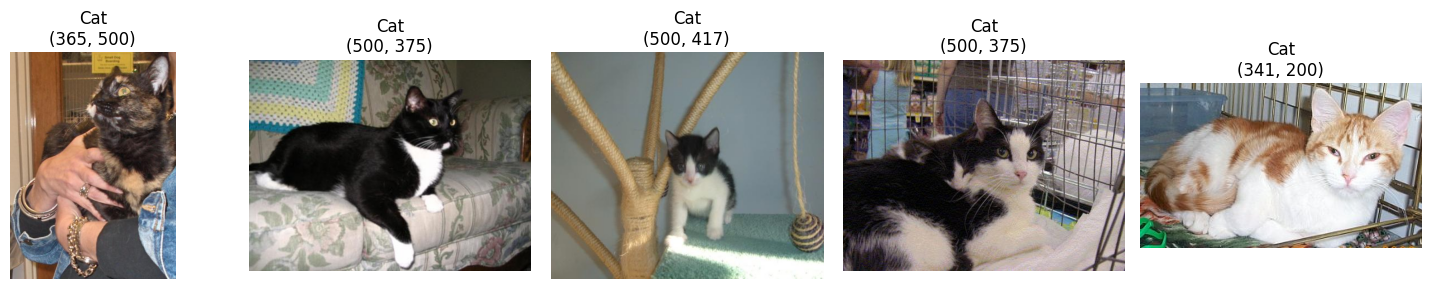

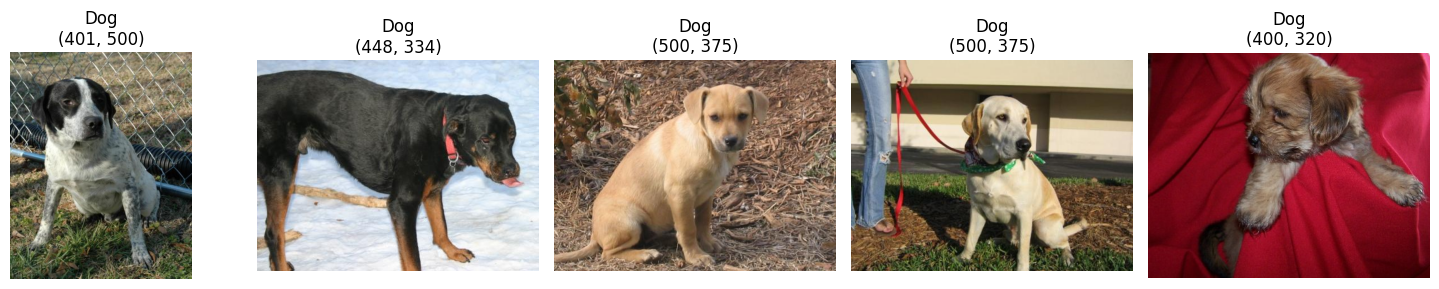

In [92]:
def show_raw_samples(folder, label, n=5):
    label_dir = os.path.join(folder, label)
    files = os.listdir(label_dir)[:n]
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, f in zip(axes, files):
        img = Image.open(os.path.join(label_dir, f))
        ax.imshow(img)
        ax.set_title(f"{label}\n{img.size}")  # shows original (width, height)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_raw_samples('data/train', 'Cat')
show_raw_samples('data/train', 'Dog')

In [6]:
class CatsDogsDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.transform = transform
        self.samples = []
        
        for label_idx, label_name in enumerate(['Cat', 'Dog']):  # Cat=0, Dog=1
            label_dir = os.path.join(folder, label_name)

            for f in os.listdir(label_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(label_dir, f), label_idx))

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(), # it simply maps [0,255] → [0,1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # it simply maps [0,1] → [-1,1]
])

In [8]:
train_ds = CatsDogsDataset('data/train', train_transform)
val_ds   = CatsDogsDataset('data/val', val_transform)

### Training — shuffle=True

During training, the model updates its weights after every batch. If the batches always come in the same order (e.g. 500 cats first, then 500 dogs), the model can develop a bias — it tunes itself toward whatever class it saw last. Shuffling ensures every batch has a random mix, leading to more stable and generalised learning.

------

### Validation — shuffle=False

During validation, you're just measuring performance — no weight updates happen. The order of images doesn't affect the result at all, since you're computing the average loss and accuracy over the entire set anyway. Keeping it ordered also has a small practical benefit: results are reproducible and consistent across runs, which makes it easier to compare experiments.

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)       

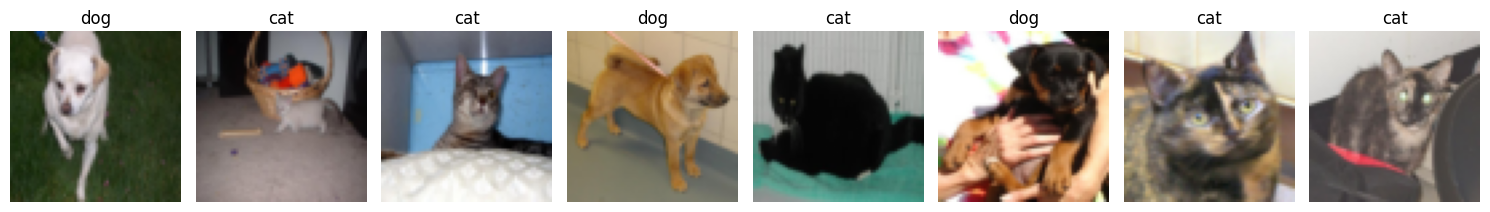

In [14]:
def show_batch(loader, n=8):
    images, labels = next(iter(loader))  # grab one batch
    images = images[:n]
    labels = labels[:n]

    # Undo normalization so colors display correctly: tensor*0.5 + 0.5
    images = images * 0.5 + 0.5
    images = images.clamp(0, 1) # Replace every value smaller than 0 with 0, and every value larger than 1 with 1.

    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    class_names = ['cat', 'dog']
    for ax, img, label in zip(axes, images, labels):
        img = img.permute(1, 2, 0).numpy()  # [C,H,W] → [H,W,C] for matplotlib
        ax.imshow(img)
        ax.set_title(class_names[label.item()])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

---------

# Our Network

## Dog-Cat-Network or DCNet

In [15]:
class DCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),             # [B, 3, 64, 64] → [B, 12288]
            nn.Linear(12288, 512),   # first hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),         # randomly drop 30% of neurons
            nn.Linear(512, 256),    # second hidden layer
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),      # output: single number
        )

    def forward(self, x):
        return self.net(x)          # returns raw logit

model = DCNet().to(device)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")  # ~6.5 million

DCNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12288, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=1, bias=True)
  )
)
Total parameters: 6,423,553


In [16]:
# Binary Cross-Entropy with logits: combines sigmoid + BCE in one step
# More numerically stable than doing them separately
criterion = nn.BCEWithLogitsLoss()

# Adam optimiser: adapts learning rate for each parameter automatically
optimizer = optim.Adam(model.parameters(), 
                       lr=1e-3,
                       weight_decay= 0.00001)

# Optional: reduce learning rate if val loss stops improving
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Understanding the loss:
# - label 0 (cat) → model should output a large negative number
# - label 1 (dog) → model should output a large positive number
# - BCE measures how far off we are and gives a gradient

# To get a probability from the model output:
# prob = torch.sigmoid(model(x))   # gives 0.0–1.0
# pred = (prob > 0.5).float()       # 0 = cat, 1 = dog

Epoch 101 | Train loss: 0.3161 acc: 0.855 | Val loss: 0.2337 acc: 0.908


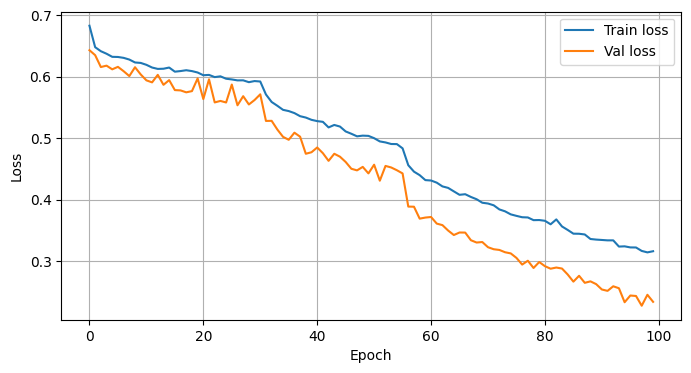

In [17]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()   # enable dropout, batch norm etc.
    total_loss, correct = 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # [B] → [B,1]
        optimizer.zero_grad()          # clear old gradients
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)# compute loss
        loss.backward()                 # backpropagate
        optimizer.step()                # update weights
        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
    
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()    # disable dropout
    total_loss, correct = 0, 0
    
    with torch.no_grad():  # no gradient tracking needed
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            
    return total_loss / len(loader), correct / len(loader.dataset)

# Run training for N epochs
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss); val_losses.append(vl_loss)

    clear_output(wait=True)

    print(f"Epoch {epoch+1:2d} | "
          f"Train loss: {tr_loss:.4f} acc: {tr_acc:.3f} | "
          f"Val loss: {vl_loss:.4f} acc: {vl_acc:.3f}")
    
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


Model saved!
Prediction: cat (81.5% confidence)


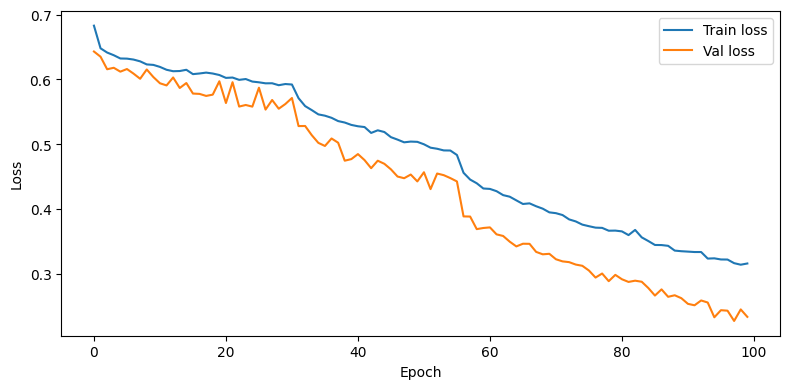

In [18]:
# ─── Save model ───────────────────────────────────────────
torch.save(model.state_dict(), 'dogs_cats_fc.pth')
print("Model saved!")

# ─── Load model later ─────────────────────────────────────
model = DCNet().to(device)
model.load_state_dict(torch.load('dogs_cats_fc.pth', map_location=device))
model.eval()

# ─── Predict on a single image ────────────────────────────
def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device) # add batch dim
    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()
    label = "dog" if prob > 0.5 else "cat"
    prob = prob if label == 'dog' else 1 - prob
    print(f"Prediction: {label} ({prob:.1%} confidence)")

predict('data/val/Cat/15.jpg')

# ─── Plot training curves ──────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()


---------

# Part 2 

## Power it with Autoencoder

![Autoencoder Architecture](autoencoder_architecture.png)

## Step 1: Build the Autoencoder

In [54]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                  # [B, 3, 64, 64] → [B, 12288]
            nn.Linear(12288, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),    # compressed representation
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 12288),
            nn.Tanh(),                     # output in range [-1, 1]
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 3, 64, 64)       # reshape back to image shape


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        reconstructed = self.decoder(z)
        return reconstructed


autoencoder = Autoencoder(latent_dim=256).to(device)
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=12288, out_features=1024, bias=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=256, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=1024, bias=True)
      (3): ReLU()
      (4): Linear(in_features=1024, out_features=12288, bias=True)
      (5): Tanh()
    )
  )
)


### Loss Function

this is different from before

MSELoss simply measures, pixel by pixel, how different the reconstructed image is from the original. There's no "cat" or "dog" involved in this loss — the autoencoder doesn't even know labels exist.

In [56]:
criterion = nn.MSELoss()   # Mean Squared Error: compares pixel values directly
optimizer = optim.Adam(autoencoder.parameters(), lr=0.0008)

## Step 2: Training Loop

Notice in criterion(reconstructed, images) — both arguments come from the same batch. The model is literally graded on how well it can recreate what you just showed it.

In [48]:
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=128, shuffle=False)       

Epoch 80 | Train loss: 0.0322 | Val loss: 0.0327 


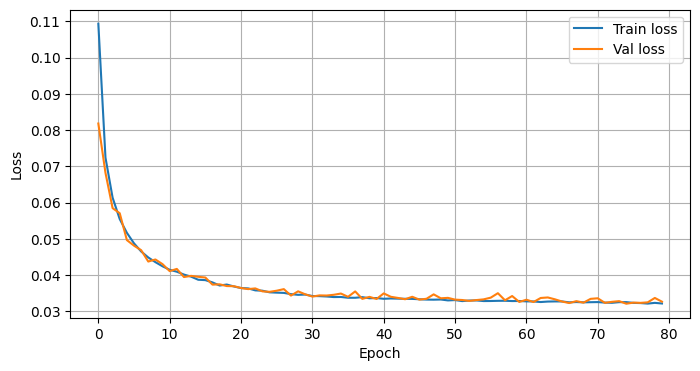

In [57]:
def train_autoencoder_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for images, _ in loader:          # labels are ignored — the "_"
        images = images.to(device)
        optimizer.zero_grad()
        reconstructed = model(images)
        loss = criterion(reconstructed, images)   # compare output to itself!
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_autoencoder_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            total_loss += loss.item()
    return total_loss / len(loader)


EPOCHS = 80
ae_train_losses, ae_val_losses = [], []
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_autoencoder_epoch(autoencoder, train_loader, criterion, optimizer)
    vl_loss = eval_autoencoder_epoch(autoencoder, val_loader, criterion)
    ae_train_losses.append(tr_loss)
    ae_val_losses.append(vl_loss)

    clear_output(wait=True)

    print(f"Epoch {epoch:2d} | "
          f"Train loss: {tr_loss:.4f} | "
          f"Val loss: {vl_loss:.4f} ")
    
    plt.figure(figsize=(8, 4))
    plt.plot(ae_train_losses, label="Train loss")
    plt.plot(ae_val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Step 3: Visualize reconstructions (sanity check)

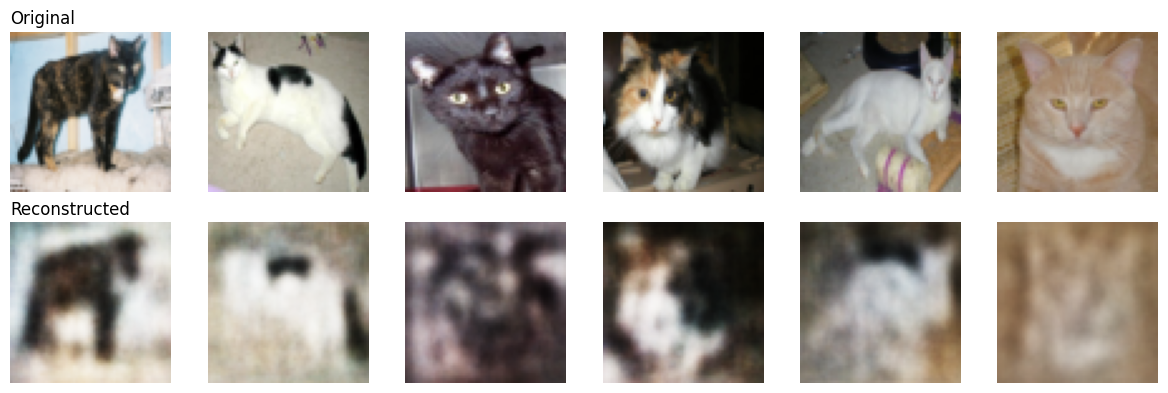

In [66]:
def show_reconstructions(model, loader, n=6):
    model.eval()
    images, _ = next(iter(loader))
    batch_size = len(images)
    idx = random.sample(range(batch_size), min(n, batch_size))
    images = images[idx].to(device)

    with torch.no_grad():
        recon = model(images)

    # Un-normalize from [-1, 1] back to [0, 1] for display
    images = (images.cpu() * 0.5 + 0.5).clamp(0, 1)
    recon  = (recon.cpu()  * 0.5 + 0.5).clamp(0, 1)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(images[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].permute(1, 2, 0))
        axes[1, i].axis('off')
    axes[0, 0].set_title('Original', loc='left')
    axes[1, 0].set_title('Reconstructed', loc='left')
    plt.tight_layout()
    plt.show()

show_reconstructions(autoencoder, val_loader)

## Step 4: Build the classifier using the pretrained Encoder

In [67]:
class ClassifierFromEncoder(nn.Module):
    def __init__(self, encoder, latent_dim=128, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False   # encoder weights won't update

        self.classifier_head = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(),
            
            nn.Linear(64,1)    # binary output
        )

    def forward(self, x):
        with torch.no_grad() if not self.encoder.training else torch.enable_grad():
            z = self.encoder(x)
        return self.classifier_head(z)

# Reuse the encoder you already trained
clf_model = ClassifierFromEncoder(autoencoder.encoder, latent_dim=256, freeze_encoder=True).to(device)

## Step 5: Train the classifier

Almost identical to before — except the optimizer should only update unfrozen parameters:

In [68]:
criterion = nn.BCEWithLogitsLoss()
# filter() skips frozen (requires_grad=False) parameters automatically
optimizer = optim.Adam(filter(lambda p: p.requires_grad, clf_model.parameters()), lr=1e-3)

# Reuse train_epoch / eval_epoch functions from before, with:
# - train_loader / val_loader using train_transform / val_transform (with Normalize)

Epoch 101 | Train loss: 0.1774 acc: 0.930 | Val loss: 0.0690 acc: 0.986


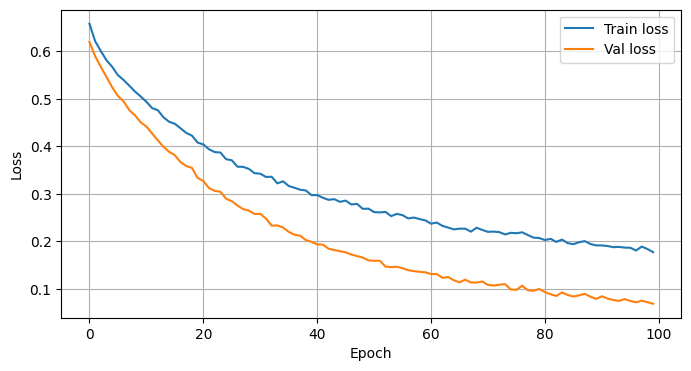

In [69]:
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(clf_model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = eval_epoch(clf_model, val_loader, criterion)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss); val_losses.append(vl_loss)

    clear_output(wait=True)

    print(f"Epoch {epoch+1:2d} | "
          f"Train loss: {tr_loss:.4f} acc: {tr_acc:.3f} | "
          f"Val loss: {vl_loss:.4f} acc: {vl_acc:.3f}")
    
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


Model saved!
Prediction: cat (80.1% confidence)


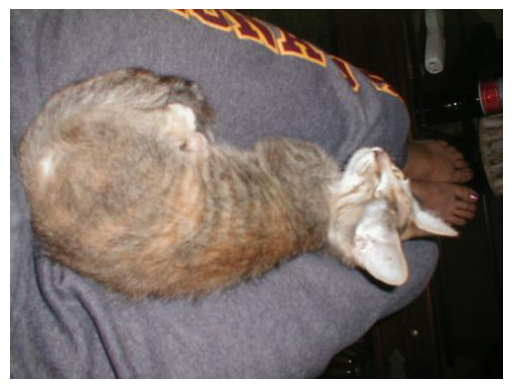

In [85]:
# ─── Save model ───────────────────────────────────────────
torch.save(clf_model.state_dict(), 'ae_dogs_cats.pth')
print("Model saved!")

# ─── Load model later ─────────────────────────────────────
model = ClassifierFromEncoder(encoder= autoencoder.encoder, latent_dim=256).to(device)
model.load_state_dict(torch.load('ae_dogs_cats.pth', map_location=device))
model.eval()

# ─── Predict on a single image ────────────────────────────
def predict(image_path):
    img = Image.open(image_path).convert('RGB')
    tensor = val_transform(img).unsqueeze(0).to(device) # add batch dim
    with torch.no_grad():
        logit = model(tensor)
        prob  = torch.sigmoid(logit).item()
    label = "dog" if prob > 0.5 else "cat"
    prob = prob if label == 'dog' else 1 - prob
    print(f"Prediction: {label} ({prob:.1%} confidence)")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

predict('data/val/Cat/24.jpg')
